In [2]:
%pip install yfinance


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 14.3 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peewee: filename=peewee-3.17.9-cp311-cp311-macosx_11_0_arm64.whl size=264489 sha256=f3902de710760cbb75dc1815f7c200aa9fa0838c72aea0c00a0cf129d75b93c6
  Stored in directory: /Users/juliastephenson/Library/Caches/pip/wheels/f4/14/e4/50c88c865833085aeb91e2bd40e3a683ff434806386b8ee7bc
Successfully built peewee
Note: you may need to restart the kernel to use updated packages.


In [31]:
import yfinance as yf
import numpy as np 

In [32]:
# Merton Model parameters 
debt = 182008 # million
equity = 59575 # million
v_t = debt + equity
print('enterprise value:', v_t)
d_e_ratio= debt/equity
print('debt to equity ratio:', d_e_ratio)

# Note that in the merton model there is only one type of debt 
# The debt is assumed to be a zero coupon bond with maturity T

# fmcc = yf.download("FMCC", period="1y")
# returns = fmcc['Adj Close'].pct_change().dropna()
# volatility = np.std(returns) * np.sqrt(252)
# print(f"Annualized volatility: {volatility:.2%}")



enterprise value: 241583
debt to equity ratio: 3.055107007973143


In [33]:
# Asset volatility 

# Market value of equity 
shares_outstanding = 650059553
share_price = 5.44 #used the closing price (4-21-25) 
market_value_equity = shares_outstanding * share_price
print("Market Value of Equity: ", market_value_equity)

#equity_volatility_sigma = .28 # This is an ESTIMATE and needs to be found still 
#asset_volatility = equity_volatility_sigma * (market_value_equity / (market_value_equity + debt))

# Risk free rate is typically determined by the yield on a 10 year treasury bond
# Use yfinance to get the current yield on a 10 year treasury bond

# Fetch the 10-Year Treasury yield index (^TNX)
tnx = yf.Ticker("^TNX")

# Get the latest data (you can also specify longer period if needed)
data = tnx.history(period="1d", interval="1m")  # minute-level for today
r_f = data['Close'].iloc[-1]  # most recent value
print('risk free rate:', r_f)

# Format as percentage
print(f"10-Year Treasury Yield: {r_f:.2f}%")

T = 10 # Long term debt 



Market Value of Equity:  3536323968.32
risk free rate: 4.265999794006348
10-Year Treasury Yield: 4.27%


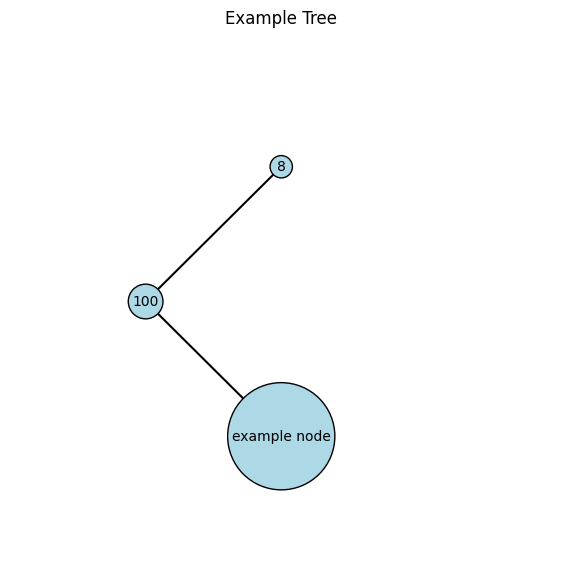

In [34]:
from matplotlib import pyplot as plt
import numpy as np

def create_tree(up, down, node1, title):
    fig, ax = plt.subplots(figsize=[7, 7])  # Increase figure size for better spacing
    ax.axis('off')  # Turn off axes labels

    # Set axis limits to prevent nodes from being cut off
    ax.set_xlim(-1, 3)
    ax.set_ylim(-2, 2)

    # Coordinates for the root node
    x, y = 0, 0
    ax.text(x, y, f"{node1}", ha='center', va='center', fontsize=10, bbox=dict(boxstyle="circle", facecolor="lightblue"))

    # Coordinates for the child nodes
    x_up, y_up = x + 1, y + 1
    x_down, y_down = x + 1, y - 1

    # Draw lines to child nodes
    ax.plot([x, x_up], [y, y_up], 'k-')
    ax.plot([x, x_down], [y, y_down], 'k-')

    # Add child nodes with their values
    ax.text(x_up, y_up, f"{up}", ha='center', va='center', fontsize=10, bbox=dict(boxstyle="circle", facecolor="lightblue"))
    ax.text(x_down, y_down, f"{down}", ha='center', va='center', fontsize=10, bbox=dict(boxstyle="circle", facecolor="lightblue"))
    plt.title(title)
    plt.show()

# Example usage
create_tree(8, 'example node', 100, 'Example Tree')


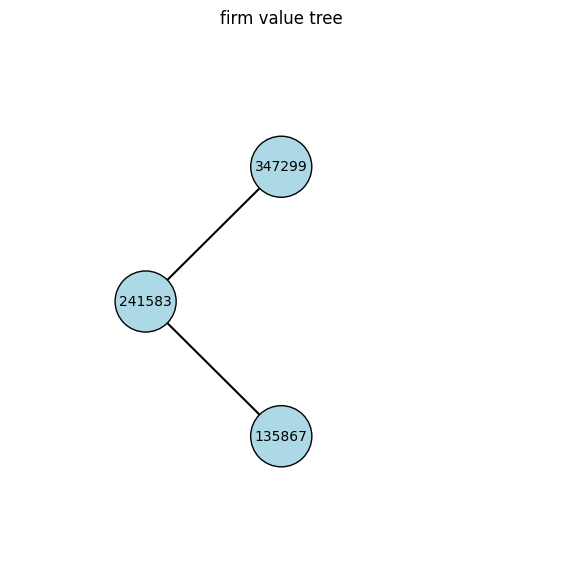

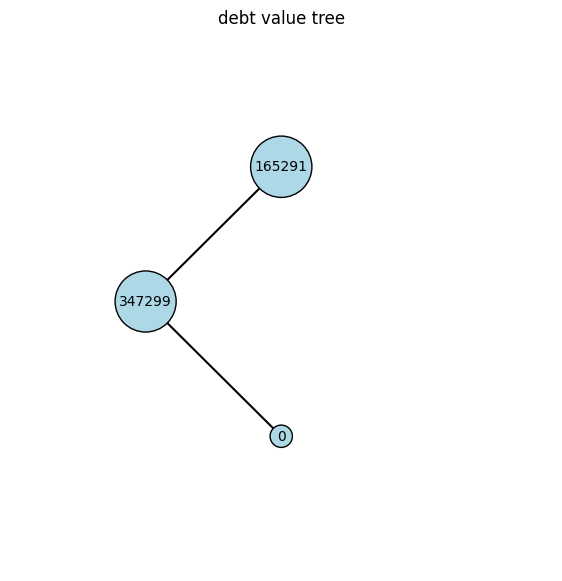

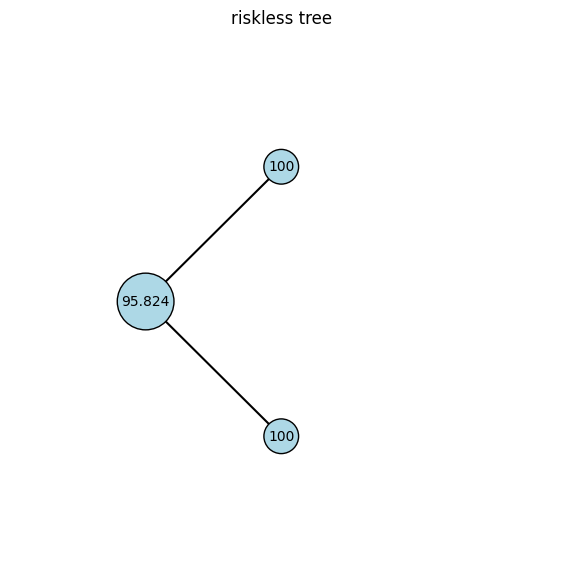

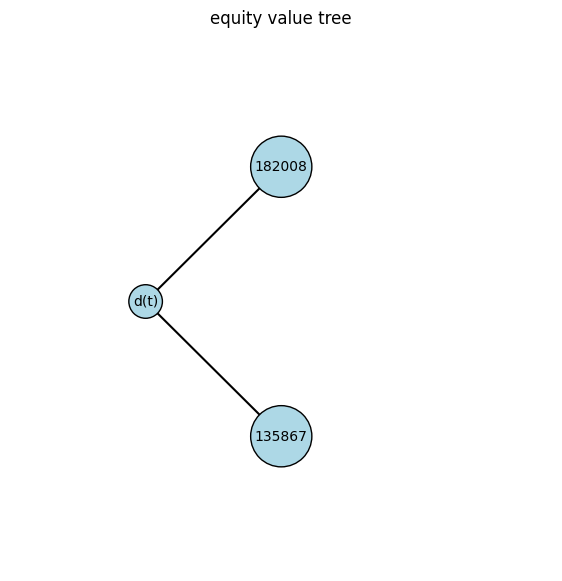

In [35]:
# Firm value tree

# Suppose the value of the firm can increase or decrease by the amount that it increased last year
# FIND amount that firm will increase or decrease by 
# One idea is to normalize the changes with some normal distribution 
# change = np.random.normal(...)
change = 105716 
v_up = v_t + change
v_down = v_t - change
create_tree(v_up, v_down, v_t, 'firm value tree')


# Debt value tree 
d_up = v_up - debt 
d_down = max(0, v_down - debt)

# visualizing the tree
create_tree(d_up, d_down, v_up, 'debt value tree')

# Riskless tree 
rf_1 = round(100 * np.exp(-r_f/100), 3) # risk free rate is in percent
rf_updown = 100 
create_tree(rf_updown, rf_updown, rf_1, 'riskless tree')

# Equity value tree (find the replicating portfolio that looks like a defaultable bond) 
e_up = v_up - d_up
e_down = v_down - d_down
create_tree(e_up, e_down, 'd(t)', 'equity value tree')





In [36]:
# finding the replicating portfolio for the value of D(t) 
def find_rep(v_up, v_down, d_up, d_down, rf_updown): 
    # Non default 
    # N1 * v_up + N2 * rf_updown = d_up
    # Default
    # N1 * v_down + N2 * rf_updown = d_down
    # Solve for N1 and N2
    N1 = (d_up - d_down) / (v_up - v_down)
    N2 = (d_up - N1 * v_up) / rf_updown
    return N1, N2
N1, N2 = find_rep(v_up, v_down, d_up, d_down, rf_updown)
print(f"N1: {N1}, N2: {N2}")

# Value of D(t) 
def d_t (n1, n2, v_t, rf_1): 
    return n1 * v_t + n2 * rf_1
d_t = d_t(N1, N2, v_t, rf_1)
print(f"Value of D(t): {d_t}")

# Rate 
def find_R(d_t): 
    return (-np.log(d_t / debt) / T) * 100
R = find_R(d_t)
print(f"Rate: {R:.2f}%")

# Credit Spread 
def find_credit_spread(R, rf): 
    return R - rf
credit_spread = find_credit_spread(R, r_f)
print(f"Credit Spread: {credit_spread:.2f}%")
print(f'risk free rate: {r_f:.2f}%')

N1: 0.7817690794203337, N2: -1062.1661951360247
Value of D(t): 87081.10603088803
Rate: 7.37%
Credit Spread: 3.11%
risk free rate: 4.27%
